In [84]:
import os
import torch
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import pickle

from torchvision import models, transforms
from sklearn.metrics.pairwise import cosine_similarity
from torch.utils.data import Dataset, DataLoader

### GPU Setup

In [85]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Load Dataset

In [86]:
df = pd.read_csv("../fashion-dataset/styles.csv", on_bad_lines='skip')


In [87]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB


In [89]:
df.isnull().sum()

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64

In [90]:
df.shape

(44424, 10)

In [91]:
df = df.dropna()


In [92]:
# add image path column
df['image_path'] = "../fashion-dataset/images/" + df['id'].astype(str) + ".jpg"
df = df[df['image_path'].apply(os.path.exists)]


In [93]:

image_paths = df['image_path'].tolist()

print("Total images:", len(image_paths))

Total images: 44072


### Load ResNet50 Model

In [94]:
model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])

model.to(device)
model.eval()

d:\ML_Project\Fashion-Recommendation-System-CNN\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\ML_Project\Fashion-Recommendation-System-CNN\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


### Image Preprocessing

In [95]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Custom Dataset (for batching)

In [96]:
class ImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        try:
            img = Image.open(path).convert('RGB')
            img = self.transform(img)
            return img, path
        except:
            return None, None

### DataLoader (GPU batching)

In [97]:
dataset = ImageDataset(image_paths, transform)

dataloader = DataLoader(
    dataset,
    batch_size=64,  
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

### Batch Feature Extraction



In [98]:
features = []   
valid_paths = []       

with torch.no_grad():
    for imgs, paths in tqdm(dataloader):

        valid_imgs = []
        valid_batch_paths = []

        for i in range(len(imgs)):
            if imgs[i] is not None:
                valid_imgs.append(imgs[i])
                valid_batch_paths.append(paths[i])

        if len(valid_imgs) == 0:
            continue

        imgs_tensor = torch.stack(valid_imgs).to(device, non_blocking=True)

        with torch.amp.autocast(device_type='cuda'):
            batch_features = model(imgs_tensor)

        batch_features = batch_features.cpu().numpy().reshape(len(valid_imgs), -1)

        features.extend(batch_features)        
        valid_paths.extend(valid_batch_paths)  

100%|██████████| 689/689 [24:12<00:00,  2.11s/it]


### Normalize Features

In [99]:
features = features / np.linalg.norm(features, axis=1, keepdims=True)

### Save Features

In [100]:
pickle.dump(features, open("../model/features.pkl", "wb"))
pickle.dump(valid_paths, open("../model/paths.pkl", "wb"))

### Load Features (later use)

In [101]:
features = pickle.load(open("../model/features.pkl", "rb"))
valid_paths = pickle.load(open("../model/paths.pkl", "rb"))

### Single Image Feature

In [102]:
def extract_features(img_path):
    img = Image.open(img_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feat = model(img)

    feat = feat.cpu().numpy().flatten()
    feat = feat / np.linalg.norm(feat)

    return feat

### Recommendation Function

In [103]:
def recommend(query_img, top_k=5):
    query_feat = extract_features(query_img)

    similarities = cosine_similarity([query_feat], features)[0]
    indices = similarities.argsort()[-top_k:][::-1]

    return indices

### Show Results

In [104]:
import matplotlib.pyplot as plt

def show_results(query_img):
    indices = recommend(query_img)

    plt.imshow(Image.open(query_img))
    plt.title("Query Image")
    plt.axis('off')
    plt.show()

    for i in indices:
        plt.imshow(Image.open(valid_paths[i]))
        plt.axis('off')
        plt.show()

### Test

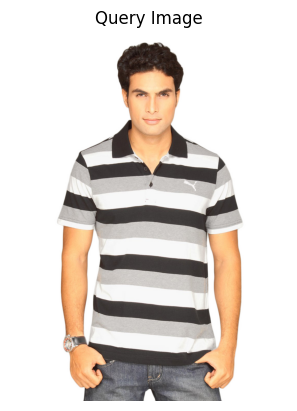

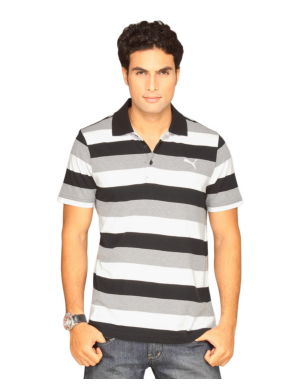

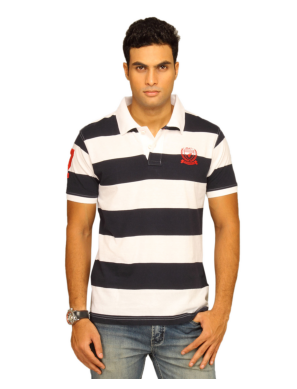

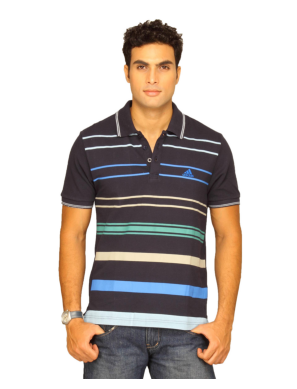

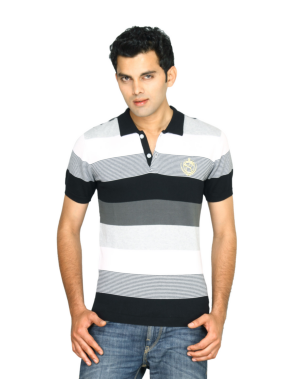

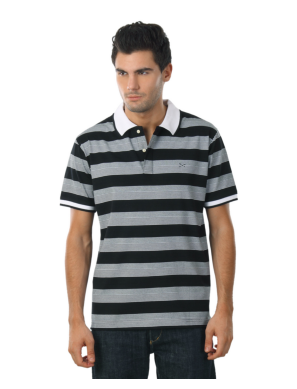

In [105]:
test_img = valid_paths[55]
show_results(test_img)